# pySCP ↔ SCP parity

Runs the R package [SCP](https://github.com/zhanghao-njmu/SCP) (Hao Zhang, NJMU, GPL-3)
and this port side by side on **SCP's own development data**, and compares what each
produces.

The risk in this port is not a crash. It is a figure that looks entirely plausible and is
subtly wrong — a palette shifted by one, a z-score off by `sqrt(n/(n-1))`, a legend in the
wrong order. None of those raise. So this notebook leans on **numeric** comparison, and
only shows pictures where a picture is the thing in question.

**Scope.** Milestone 1 (the foundation) and `cell_dim_plot` are implemented; everything
else in `scp.pl` still raises `NotImplementedError`. Each milestone should append a section
here as it lands. See `docs/07_milestones.md`.

## Setup

Both halves run in one conda environment (`scp_parity`) so that rpy2 links against the same
R that has SCP installed.

In [1]:
import warnings, pathlib
warnings.filterwarnings("ignore")

import anndata as ad, numpy as np, pandas as pd, matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import HTML, display

import scp

ROOT = pathlib.Path.cwd()
if not (ROOT / "notebooks").exists():
    ROOT = ROOT.parent
DATA = ROOT / "notebooks" / "data"
FIG  = ROOT / "notebooks" / "figures"
FIG.mkdir(exist_ok=True, parents=True)

print("pySCP", scp.__version__, "| anndata", ad.__version__, "| matplotlib", matplotlib.__version__)

pySCP 0.0.1.dev0 | anndata 0.13.3.post0 | matplotlib 3.11.1


In [2]:
import rpy2.rinterface_lib.callbacks as cb

# rpy2 makes R's interactive() return TRUE, so SCP's askYesNo guards raise a
# menu and block on stdin forever instead of being skipped as they are under
# Rscript. FeatureStatPlot(plot_type="bar") hits one. Answer them rather than
# hang -- and note this is exactly the behaviour the port replaces with
# force=True, per docs/08_agent_handoff.md: an interactive guard inside a
# library is a hang waiting to happen.
cb.consoleread = lambda prompt: "1\n"

%load_ext rpy2.ipython

In [3]:
%%R
suppressPackageStartupMessages(library(SCP))
cat("SCP", as.character(packageVersion("SCP")),
    "| Seurat", as.character(packageVersion("Seurat")),
    "|", R.version.string, "\n")

SCP

0.5.6

| Seurat

5.5.1

|

R version 4.5.3 (2026-03-11)

## 1. The data

`pancreas_sub` is the dataset behind 21 of the 22 plotting examples in `SCP-plot.R`: 1000
mouse pancreatic endocrinogenesis cells (Bastidas-Ponce et al. 2019), downsampled by SCP
with `set.seed(11)`.

It reaches Python through `tools/export_scp_data.R` → `tools/build_parity_h5ad.py`. That
route exists because the three off-the-shelf converters all fail here: `sceasy` calls
`GetAssayData(slot=)`, defunct in SeuratObject 5; `zellkonverter` routes through basilisk,
which tries to build its own Python; and SCP's own `srt_to_adata` manages a conda
environment by name and will *replace* an existing one. The export replicates
`srt_to_adata`'s documented mapping explicitly instead.

Two deliberate divergences from that mapping, both so the comparison is meaningful:

- **`X` carries the `data` slot, not `counts`.** `srt_to_adata` defaults to `counts`, but
  every plot in `SCP-plot.R` defaults to `slot="data"` and pySCP reads `adata.X` when
  `layer=None`. Counts are kept in `layers['counts']`.
- **Embeddings are renamed to scanpy convention** — `X_pca`, `X_umap`, not Seurat's
  verbatim `PCA`/`UMAP` — so pySCP works on ordinary scanpy objects out of the box.

In [4]:
%%R
data("pancreas_sub", package = "SCP")
cat("cells x genes :", ncol(pancreas_sub), "x", nrow(pancreas_sub), "\n")
cat("reductions    :", names(pancreas_sub@reductions), "\n")
cat("CellType      :", levels(pancreas_sub$CellType), "\n")

cells x genes :

1000

x

15958

reductions    :

...

Ductal

Ngn3 low EP

Ngn3 high EP

Pre-endocrine

Endocrine

In [5]:
adata = ad.read_h5ad(DATA / "pancreas_sub.h5ad")
print("cells x genes :", adata.shape)
print("obsm          :", list(adata.obsm))
print("layers        :", [k for k in adata.layers])
print("CellType      :", list(adata.obs["CellType"].cat.categories))

cells x genes : (1000, 15958)
obsm          : ['X_pca', 'X_umap']
layers        : ['counts', 'spliced', 'unspliced', None]
CellType      : ['Ductal', 'Ngn3 low EP', 'Ngn3 high EP', 'Pre-endocrine', 'Endocrine']


### 1.1 Level order

`factor(x, levels = unique(x))` in R is order of **first appearance**, deliberately
bypassing R's own sorting. pandas sorts by default, so a naive `pd.Categorical` reshuffles
every palette and legend relative to the R output. This is the single most consequential
thing to get right, so it is checked first.

In [6]:
r_levels = %R levels(pancreas_sub$CellType)
r_levels = [str(x) for x in r_levels]
py_levels = list(adata.obs["CellType"].cat.categories)
print("R     :", r_levels)
print("pySCP :", py_levels)
assert r_levels == py_levels, "LEVEL ORDER DIVERGED"
print("\nmatch ✓")

R     : ['Ductal', 'Ngn3 low EP', 'Ngn3 high EP', 'Pre-endocrine', 'Endocrine']
pySCP : ['Ductal', 'Ngn3 low EP', 'Ngn3 high EP', 'Pre-endocrine', 'Endocrine']

match ✓


### 1.2 `default_reduction` and the embedding key

`DefaultReduction` short-circuits on a single candidate and otherwise tie-breaks on
**fewest columns**, so a 2-column UMAP beats a 50-column PCA regardless of the priority
list.

The axis-label key is the interesting case. Seurat's `@key` has no AnnData counterpart, and
`pancreas_sub` came *from* an h5ad originally, so its keys are lowercase (`umap_`) rather
than the uppercase SCP generates natively (`UMAP_`). pySCP regenerates the key from the
obsm name, which yields uppercase.

In [7]:
print("pySCP default_reduction :", scp.default_reduction(adata))
print("pySCP reduction_key     :", repr(scp.fetch.reduction_key("X_umap")))
print("R     Seurat @key       :", repr(adata.uns["scp"]["reduction_keys"]["UMAP"]))
print("\nSo R labels axes umap_1/umap_2 and pySCP labels them UMAP_1/UMAP_2.")
print("Cosmetic, but it is a real divergence -- see the figure in section 5.")

pySCP default_reduction : X_umap
pySCP reduction_key     : 'UMAP_'
R     Seurat @key       : 'umap_'

So R labels axes umap_1/umap_2 and pySCP labels them UMAP_1/UMAP_2.
Cosmetic, but it is a real divergence -- see the figure in section 5.


## 2. Palettes

229 palettes, extracted from SCP's own `.rda`. The rule that matters: when
`len(levels) <= len(palette)` the first *n* colours are taken **verbatim**. Interpolating
instead — the obvious implementation — shifts every categorical figure.

In [8]:
%%R -o r_paired,r_spectral100,r_celltype
r_paired     <- unname(palette_scp(c("a","b","c"), palette = "Paired"))
r_spectral100<- unname(palette_scp(palette = "Spectral", n = 100))
r_celltype   <- unname(palette_scp(levels(pancreas_sub$CellType), palette = "Paired"))

In [9]:
py_paired    = list(scp.discrete_palette(["a","b","c"], palette="Paired").values())
py_celltype  = list(scp.discrete_palette(py_levels, palette="Paired").values())
py_spectral  = scp.continuous_palette(palette="Spectral", n=100)

def rgb(h):
    h = h.lstrip("#")
    return np.array([int(h[i:i+2], 16) for i in (0, 2, 4)])

def compare(name, r, p, tol):
    # tol=0 for the verbatim-slice branch, 1 for the interpolated branch.
    # docs/06_testing.md pins color_ramp to grDevices::colorRampPalette within
    # one 8-bit step: R and matplotlib round the ramp differently, so exact
    # equality is the wrong bar for an interpolated palette, while a verbatim
    # slice must be byte-identical.
    d = np.array([np.abs(rgb(a) - rgb(b)).max() for a, b in zip(r, p)])
    ok = d.max() <= tol
    print(f"{name:26s} n={len(r):3d}  max channel delta={d.max()}  "
          f"tolerance={tol}  pass={ok}")
    return ok

rows = [("palette_scp(3, Paired)",  list(r_paired),       py_paired,          0),
        ("palette_scp(CellType)",   list(r_celltype),     py_celltype,        0),
        ("Spectral n=100",          list(r_spectral100),  list(py_spectral),  1)]
for name, r, p, tol in rows:
    compare(name, r, p, tol)

palette_scp(3, Paired)     n=  3  max channel delta=0  tolerance=0  pass=True
palette_scp(CellType)      n=  5  max channel delta=0  tolerance=0  pass=True
Spectral n=100             n=100  max channel delta=1  tolerance=1  pass=True


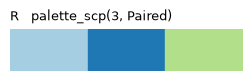

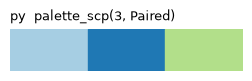

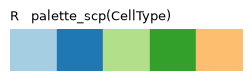

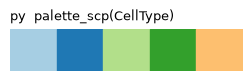

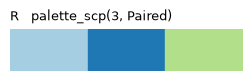

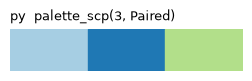

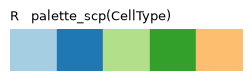

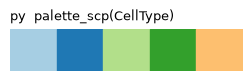

In [10]:
def swatch(colors, title):
    fig, ax = plt.subplots(figsize=(max(3, len(colors)*0.22), 0.55))
    for i,c in enumerate(colors):
        ax.add_patch(plt.Rectangle((i,0),1,1,color=c))
    ax.set_xlim(0,len(colors)); ax.set_ylim(0,1); ax.axis("off")
    ax.set_title(title, fontsize=9, loc="left")
    return fig

for name, r, p, _tol in rows[:2]:
    display(swatch(list(r), f"R   {name}"))
    display(swatch(list(p), f"py  {name}"))

## 3. Colour algebra

`blendcolors` folds a list pairwise with weight `1/N` rather than taking a naive mean, and
`adjcolors` composites over white. Both are used by `feature_dim_plot`'s
`compare_features=True` path, so they have to match before that milestone lands.

In [11]:
%%R -o r_blend,r_adj
modes <- c("blend","average","screen","multiply")
r_blend <- sapply(modes, function(m) blendcolors(c("red","green"), mode = m))
r_adj   <- adjcolors("#FF0000", 0.1)

In [12]:
modes = ["blend","average","screen","multiply"]
print(f"{'mode':10s} {'R':>9s} {'pySCP':>9s}   match")
for m, rv in zip(modes, list(r_blend)):
    pv = scp.blendcolors(["#FF0000","#00FF00"], mode=m)
    print(f"{m:10s} {rv:>9s} {str(pv):>9s}   {rv.upper()==str(pv).upper()}")
pa = scp.adjcolors("#FF0000", 0.1)
print(f"\nadjcolors  R={list(r_adj)[0]}  pySCP={pa}  match={list(r_adj)[0].upper()==pa.upper()}")

mode               R     pySCP   match
blend        #AA5500   #AA5500   True
average      #9F9F40   #9F9F40   True
screen       #FFFF40   #FFFF40   True
multiply     #404040   #404040   True

adjcolors  R=#FFE6E6  pySCP=#FFE6E6  match=True


## 4. Matrix transforms

`matrix_process` is where an off-by-`sqrt(n/(n-1))` hides. R's `scale()` uses the **sample**
standard deviation (`ddof=1`); numpy defaults to the population one.

In [13]:
%%R -o r_zscore,r_log2fc
M <- matrix(c(1,2,3,4,4,4), nrow = 2, byrow = TRUE)
# matrix_process is internal to SCP, hence the ::: 
r_zscore <- as.vector(SCP:::matrix_process(M, "zscore"))
r_log2fc <- as.vector(SCP:::matrix_process(M, "log2fc"))

In [14]:
M = np.array([[1.,2.,3.],[4.,4.,4.]])
for label, rvec in (("zscore", r_zscore), ("log2fc", r_log2fc)):
    pv = scp.matrix_process(M, label)
    rv = np.asarray(rvec).reshape(pv.shape, order="F")
    ok = np.allclose(np.nan_to_num(rv, nan=0, neginf=-1e9),
                     np.nan_to_num(pv, nan=0, neginf=-1e9))
    print(f"{label:8s} R={np.round(rv,4).tolist()}  pySCP={np.round(pv,4).tolist()}  match={ok}")

zscore   R=[[-1.0, 0.0, 1.0], [nan, nan, nan]]  pySCP=[[-1.0, 0.0, 1.0], [nan, nan, nan]]  match=True
log2fc   R=[[-1.0, 0.0, 0.585], [0.0, 0.0, 0.0]]  pySCP=[[-1.0, 0.0, 0.585], [0.0, 0.0, 0.0]]  match=True


## 5. `cell_dim_plot` vs `CellDimPlot`

The behaviours that define this figure, and that are easy to lose:

- every split panel keeps **all** cells, those outside the split drawn in `bg_color`;
- axis limits come from the **global** embedding range so panels stay comparable;
- labels sit at the per-group **marginal median** of x and y — not a medoid;
- with `label_insitu=False` the panel shows `1, 2, 3 ...` and the legend reads `1: Ductal`;
- `show_stat=True` appends per-level counts.

In [15]:
%%R
p <- CellDimPlot(pancreas_sub, group.by = "CellType", reduction = "UMAP", label = TRUE)
# ragg is mis-linked against freetype in this environment; cairo is reliable.
ggplot2::ggsave("figures/r_celldim_celltype.png", p, width = 6, height = 5,
                dpi = 110, device = grDevices::png, type = "cairo")

In addition: Warning message:
No shared levels found between `names(values)` of the manual scale and the
data's fill values. 


R — SCP,Python — pySCP
,

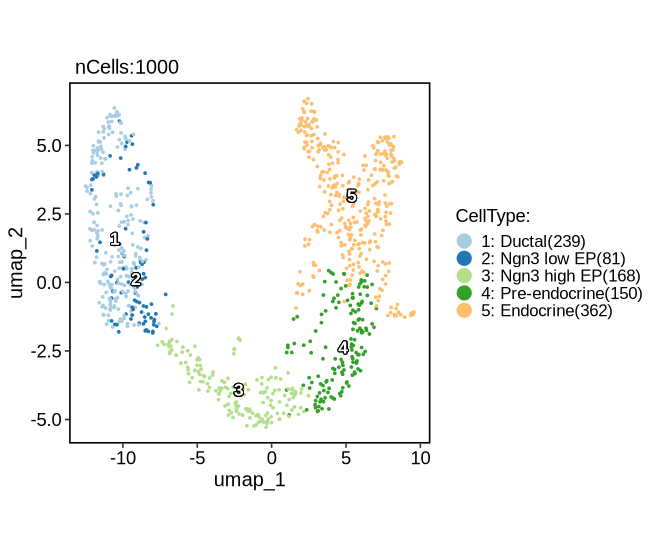
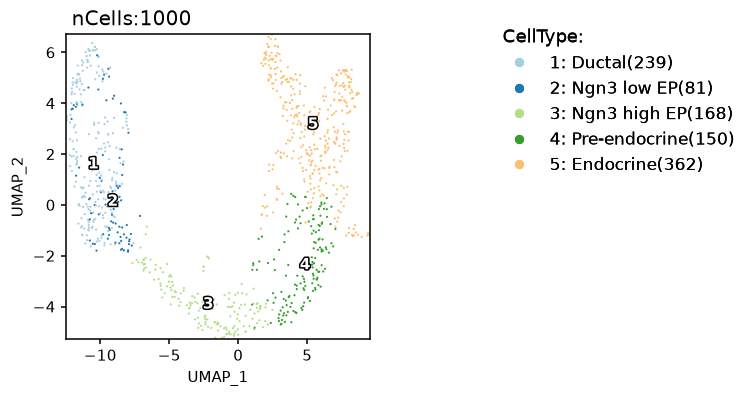

In [16]:
fig = scp.pl.cell_dim_plot(adata, "CellType", label=True)
fig.savefig(FIG / "py_celldim_celltype.png", dpi=110, bbox_inches="tight")
plt.close(fig)

import base64

def side_by_side(left, right, lt="R — SCP", rt="Python — pySCP"):
    # base64 rather than a relative src, so the comparison survives being
    # viewed on GitHub or anywhere figures/ is not alongside the notebook.
    def uri(name):
        return "data:image/png;base64," + base64.b64encode((FIG / name).read_bytes()).decode()
    return HTML(f'''
    <table style="width:100%;table-layout:fixed;border:0">
      <tr><th style="text-align:left">{lt}</th><th style="text-align:left">{rt}</th></tr>
      <tr>
        <td><img src="{uri(left)}" style="width:100%"></td>
        <td><img src="{uri(right)}" style="width:100%"></td>
      </tr>
    </table>''')

side_by_side("r_celldim_celltype.png", "py_celldim_celltype.png")

### 5.1 The legend, compared as text

The picture is the wrong instrument for checking order and counts. The legend labels carry
both, so compare those directly.

In [17]:
%%R -o r_labels
# get_guide_data reads the labels off the built legend -- what the reader
# actually sees -- rather than guessing at the scale internals.
r_labels <- as.character(ggplot2::get_guide_data(p, "colour")$.label)

In addition: Warning message:
No shared levels found between `names(values)` of the manual scale and the
data's fill values. 


In [18]:
r_labels = [str(x) for x in r_labels]
_fig = scp.pl.cell_dim_plot(adata, "CellType", label=True)
py_labels = [t.get_text() for t in _fig.legends[0].get_texts()]
plt.close(_fig)
print("R     :", r_labels)
print("pySCP :", py_labels)
print("\nidentical:", r_labels == py_labels)

R     : ['1: Ductal(239)', '2: Ngn3 low EP(81)', '3: Ngn3 high EP(168)', '4: Pre-endocrine(150)', '5: Endocrine(362)']
pySCP : ['1: Ductal(239)', '2: Ngn3 low EP(81)', '3: Ngn3 high EP(168)', '4: Pre-endocrine(150)', '5: Endocrine(362)']

identical: True


## 6. `feature_dim_plot` vs `FeatureDimPlot`

The second figure family, and the one where the conventions are least obvious:

- **draw order is ascending value with NaN first**, so the highest expressers
  land on top. Reverse it and the plot systematically hides its own signal;
- `bg_cutoff=0` NaN-masks every value **<= 0 before plotting**, so exact zeros
  are background. Signed scores (PC loadings, S_score) need `bg_cutoff=None`;
- colour limits are **winsorized** at `upper_quantile=0.99` -- values above are
  saturated, never hidden -- and `keep_scale` sets the pooling scope;
- unlike `cell_dim_plot` this genuinely **partitions** on `split_by`: a split
  panel holds only its own cells, with no grey "other split" points.

The subtitle reports positive cells and their share, not the panel total.

In [19]:
%%R
p2 <- FeatureDimPlot(pancreas_sub, features = c("Ins1","Gcg","Sst","Ghrl"),
                     reduction = "UMAP", ncol = 4)
ggplot2::ggsave("figures/r_featuredim.png", p2, width = 16, height = 4.2,
                dpi = 110, device = grDevices::png, type = "cairo")

R — SCP,Python — pySCP
,

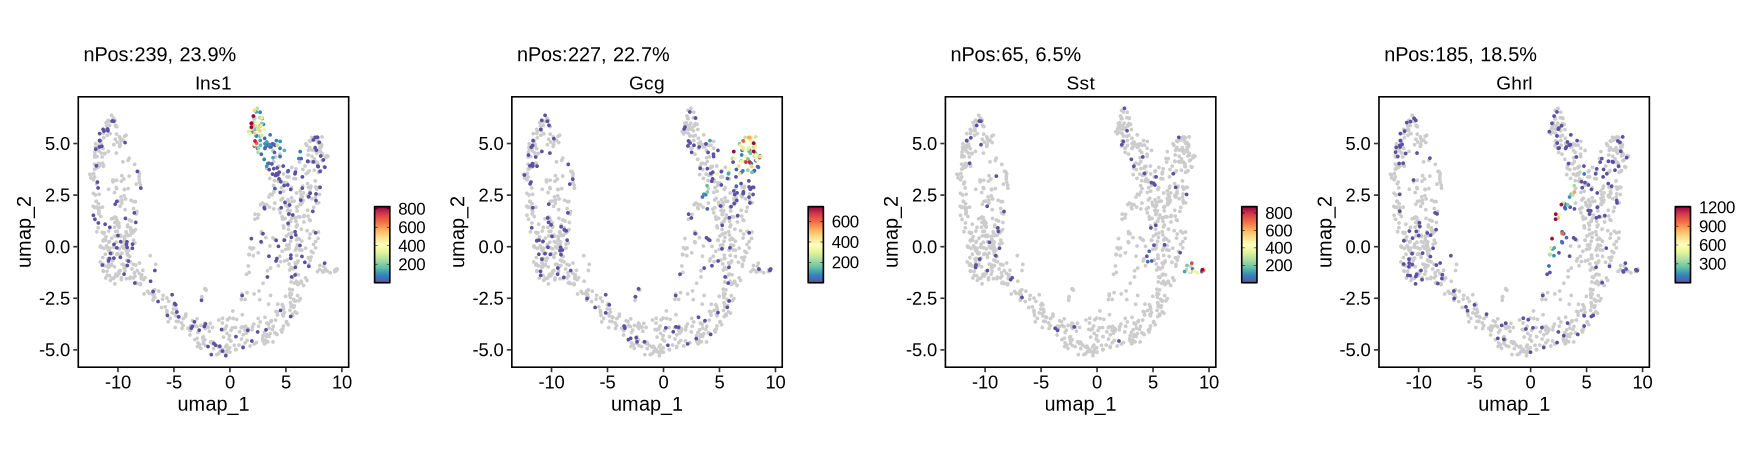
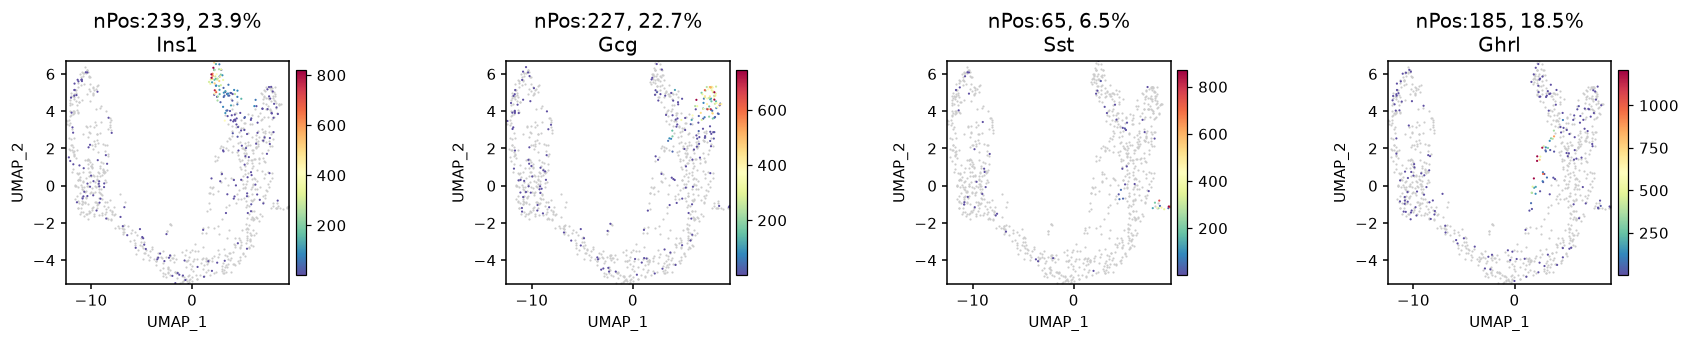

In [20]:
fig = scp.pl.feature_dim_plot(adata, ["Ins1","Gcg","Sst","Ghrl"], ncol=4, panel_size=(2.9, 2.9))
fig.savefig(FIG / "py_featuredim.png", dpi=110, bbox_inches="tight")
plt.close(fig)
side_by_side("r_featuredim.png", "py_featuredim.png")

### 6.1 The subtitles, compared as text

`nPos` and its percentage are computed from the data, so they are the cheap
numeric check on whether both sides masked the same cells at the same cutoff.

In [21]:
%%R -o r_sub
r_sub <- sapply(c("Ins1","Gcg","Sst","Ghrl"), function(f) {
  v <- SeuratObject::LayerData(pancreas_sub, layer = "data")[f, ]
  n <- sum(v > 0)
  sprintf("nPos:%d, %.1f%%", n, 100 * n / length(v))
})

In [22]:
py_sub = []
for f in ["Ins1","Gcg","Sst","Ghrl"]:
    fg = scp.pl.feature_dim_plot(adata, f)
    py_sub.append([ax for ax in fg.axes if ax.get_label() != "<colorbar>"][0]
                  .get_title().split(chr(10))[0])
    plt.close(fg)
for f, r, p in zip(["Ins1","Gcg","Sst","Ghrl"], [str(x) for x in r_sub], py_sub):
    print(f"{f:6s} R={r:22s} pySCP={p:22s} match={r == p}")

Ins1   R=nPos:239, 23.9%        pySCP=nPos:239, 23.9%        match=True
Gcg    R=nPos:227, 22.7%        pySCP=nPos:227, 22.7%        match=True
Sst    R=nPos:65, 6.5%          pySCP=nPos:65, 6.5%          match=True
Ghrl   R=nPos:185, 18.5%        pySCP=nPos:185, 18.5%        match=True


### 6.2 The blend path

With `compare_features=True` each feature gets a private two-stop ramp from a
10%-tint of its hue up to the full hue, the per-cell colours are blended, and
the points are sorted brightest-first so the most co-expressing cells end up on
top. Cells with no signal on any feature are painted `bg_color`.

In [23]:
%%R
p3 <- FeatureDimPlot(pancreas_sub, features = c("Ins1","Gcg"), reduction = "UMAP",
                     compare_features = TRUE)
ggplot2::ggsave("figures/r_featuredim_blend.png", p3, width = 6.5, height = 5,
                dpi = 110, device = grDevices::png, type = "cairo")

R — SCP,Python — pySCP
,

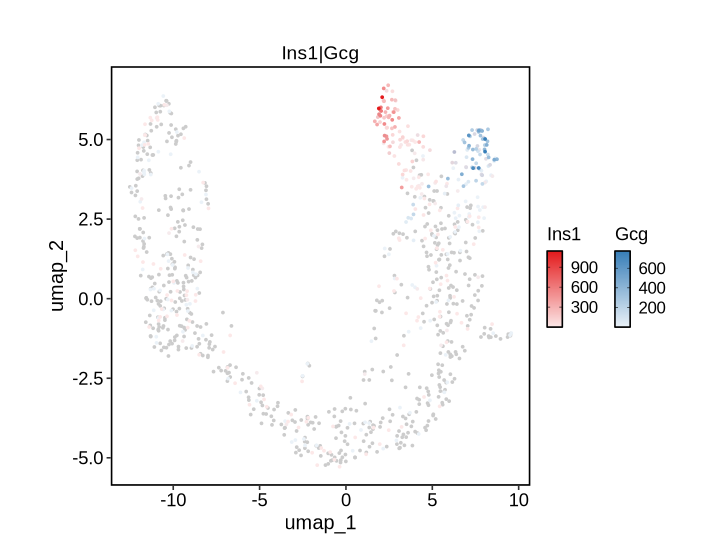
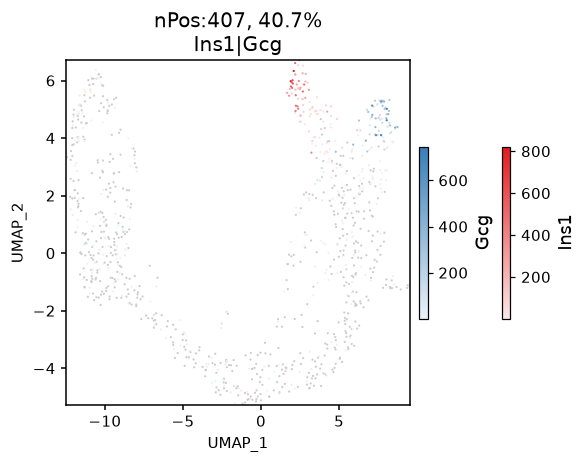

In [24]:
fig = scp.pl.feature_dim_plot(adata, ["Ins1","Gcg"], compare_features=True,
                              panel_size=(3.2, 3.2))
fig.savefig(FIG / "py_featuredim_blend.png", dpi=110, bbox_inches="tight")
plt.close(fig)
side_by_side("r_featuredim_blend.png", "py_featuredim_blend.png")

## 7. `feature_stat_plot` vs `FeatureStatPlot`

Five geometries over the same grammar: `violin`, `box`, `bar`, `dot`, `col`.

First, a caveat that shows up immediately on this object. `pancreas_sub` reached
Seurat from an h5ad, so its `data` slot holds **raw counts**, and a violin of raw
counts is a flat line at zero with one spike. That is what both packages draw,
faithfully and uselessly. Normalising first is what anyone actually does, and it
doubles as a data-contract check: Seurat's `NormalizeData` and scanpy's
`normalize_total(1e4) + log1p` are the same transform, so if the two sides agree
here the distributions below are comparable.

In [25]:
%%R -o r_norm
pn <- Seurat::NormalizeData(pancreas_sub, verbose = FALSE)
r_norm <- as.numeric(t(as.matrix(
  SeuratObject::LayerData(pn, layer = "data")[c("Ins1", "Gcg"), ])))

In [26]:
import scanpy as sc
adata_n = adata.copy()
adata_n.X = adata_n.layers["counts"].copy()
sc.pp.normalize_total(adata_n, target_sum=1e4)
sc.pp.log1p(adata_n)

py_norm = np.asarray(adata_n[:, ["Ins1", "Gcg"]].X.todense()).ravel()
delta = np.abs(np.sort(np.asarray(r_norm)) - np.sort(py_norm)).max()
print(f"Seurat NormalizeData vs scanpy normalize_total+log1p: max abs diff = {delta:.2e}")
print("same transform:", bool(delta < 1e-5))

Seurat NormalizeData vs scanpy normalize_total+log1p: max abs diff = 2.84e-07
same transform: True


### 7.1 Violin, with the box overlay

Note the alternating background stripes. They are **not** opt-in: with no
`bg_by`, SCP still stripes by `group_by`, alternating `transparent` and `grey85`
at `bg_alpha=0.2` rather than using `bg_palette` (`SCP-plot.R:3991`). Miss that
and the figure reads as subtly flatter than the original.

In [27]:
%%R
p4 <- FeatureStatPlot(pn, stat.by = c("Ins1","Gcg"), group.by = "CellType",
                      plot_type = "violin", add_box = TRUE)
ggplot2::ggsave("figures/r_featurestat_violin.png", p4, width = 10, height = 4,
                dpi = 110, device = grDevices::png, type = "cairo")

In addition: Warning messages:
1: No shared levels found between `names(values)` of the manual scale and the
data's colour values. 
2: No shared levels found between `names(values)` of the manual scale and the
data's colour values. 


R — SCP,Python — pySCP
,

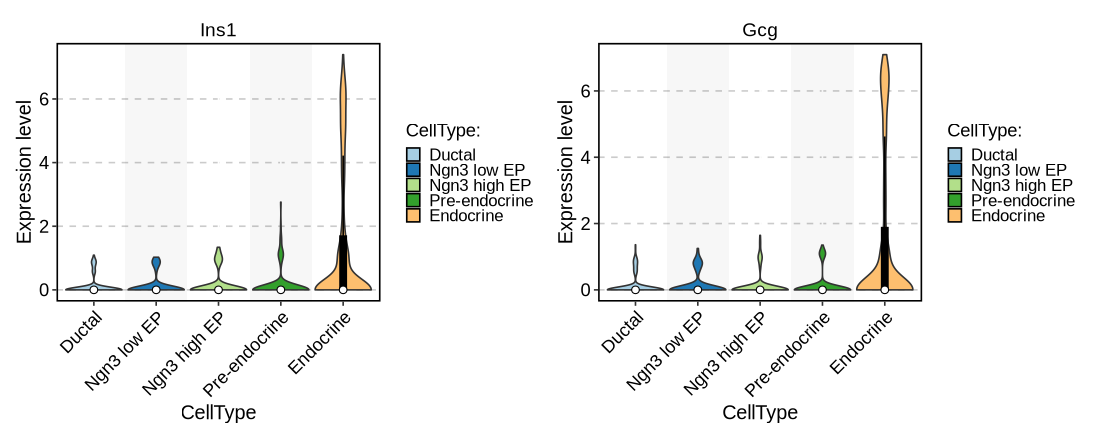
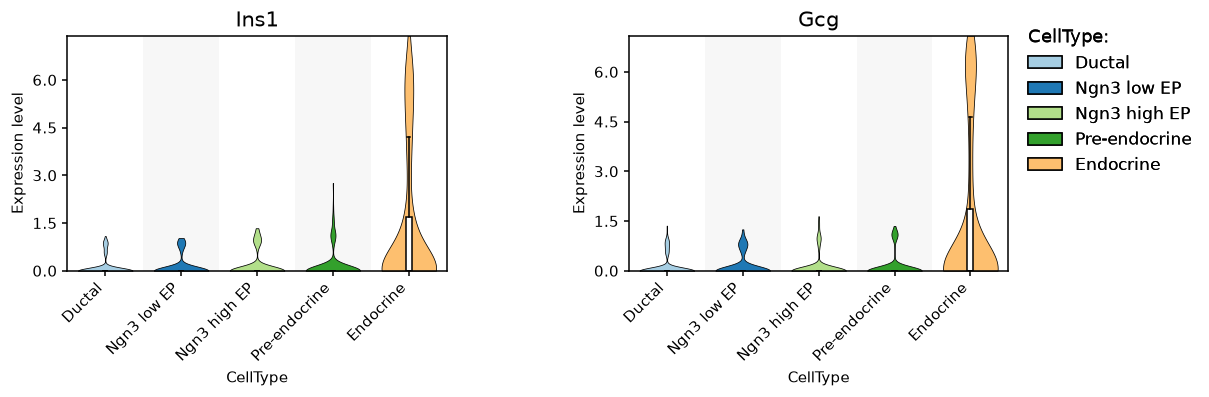

In [28]:
fig = scp.pl.feature_stat_plot(adata_n, ["Ins1","Gcg"], group_by="CellType",
                               add_box=True, ncol=2, panel_size=(3.2, 2.6))
fig.savefig(FIG / "py_featurestat_violin.png", dpi=110, bbox_inches="tight")
plt.close(fig)
side_by_side("r_featurestat_violin.png", "py_featurestat_violin.png")

### 7.2 The other geometries

`box`, `bar` and `dot` on one gene. `dot` is the one with a hidden rule: values
are cut into **14 equal-width bins**, each bin collapses to its midpoint, and the
dot is sized by how many cells land in it -- it is not a scatter.

In [29]:
%%R
pb <- FeatureStatPlot(pn, stat.by = "Ins1", group.by = "CellType", plot_type = "box")
ggplot2::ggsave("figures/r_featurestat_box.png", pb, width = 5.5, height = 4,
                dpi = 110, device = grDevices::png, type = "cairo")

In addition: Warning message:
No shared levels found between `names(values)` of the manual scale and the
data's colour values. 


In [30]:
%%R
pb <- FeatureStatPlot(pn, stat.by = "Ins1", group.by = "CellType", plot_type = "bar")
ggplot2::ggsave("figures/r_featurestat_bar.png", pb, width = 5.5, height = 4,
                dpi = 110, device = grDevices::png, type = "cairo")

In addition: Warning message:
No shared levels found between `names(values)` of the manual scale and the
data's colour values. 


In [31]:
%%R
pb <- FeatureStatPlot(pn, stat.by = "Ins1", group.by = "CellType", plot_type = "dot")
ggplot2::ggsave("figures/r_featurestat_dot.png", pb, width = 5.5, height = 4,
                dpi = 110, device = grDevices::png, type = "cairo")

In addition: Warning message:
No shared levels found between `names(values)` of the manual scale and the
data's colour values. 


R — SCP,Python — pySCP
,

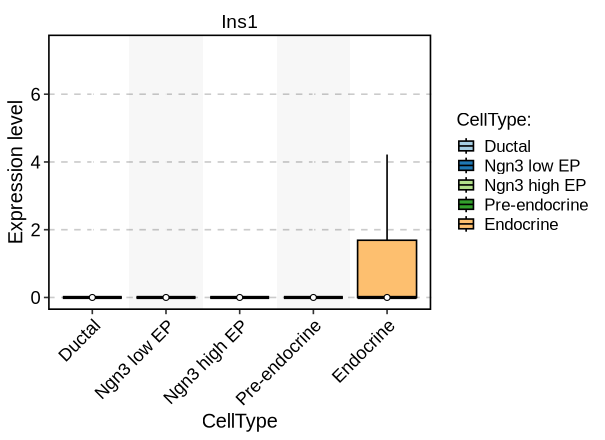
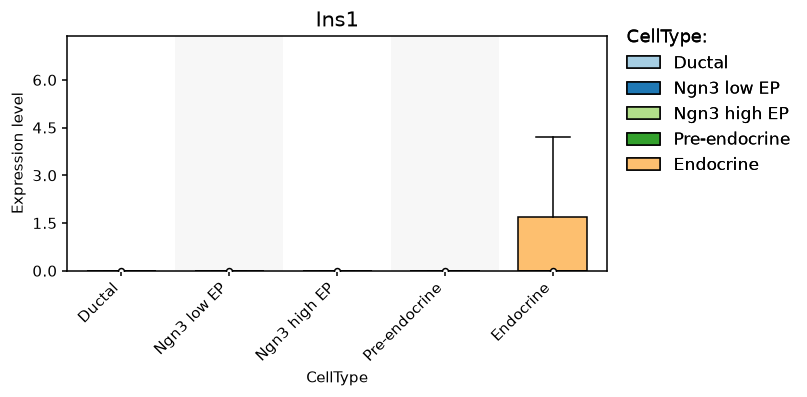

R — SCP,Python — pySCP
,

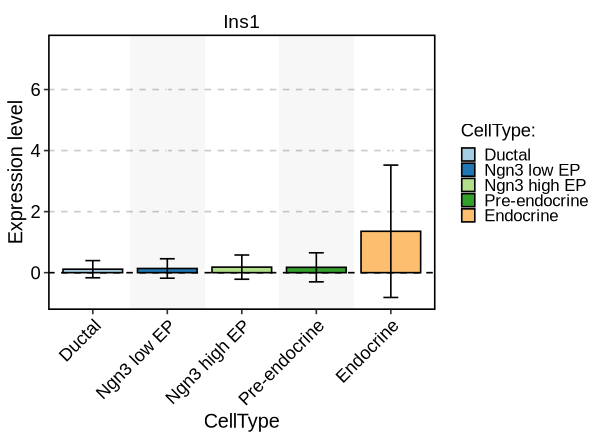
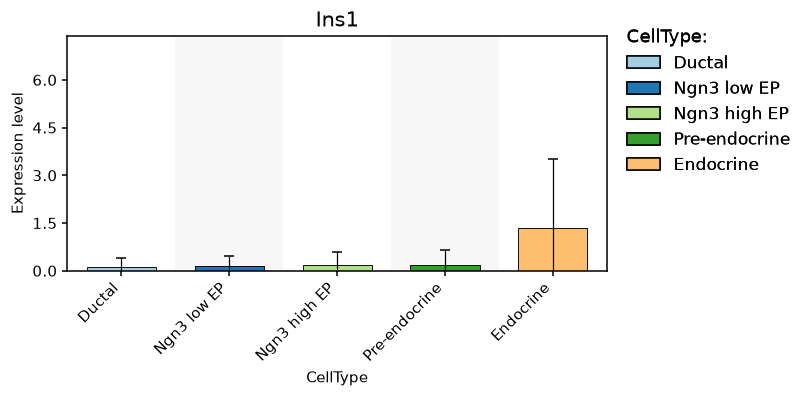

R — SCP,Python — pySCP
,

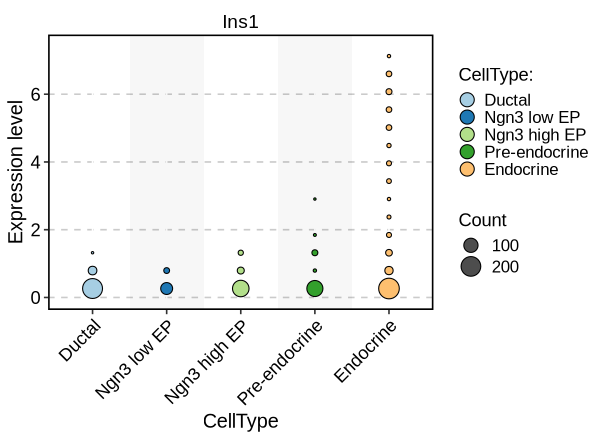
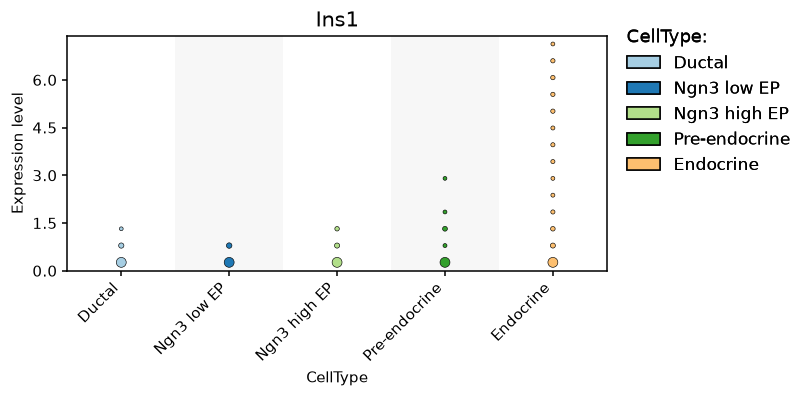

In [32]:
for t in ("box", "bar", "dot"):
    fg = scp.pl.feature_stat_plot(adata_n, "Ins1", group_by="CellType",
                                  plot_type=t, panel_size=(3.2, 2.6))
    fg.savefig(FIG / f"py_featurestat_{t}.png", dpi=110, bbox_inches="tight")
    plt.close(fg)

display(side_by_side("r_featurestat_box.png", "py_featurestat_box.png"))
display(side_by_side("r_featurestat_bar.png", "py_featurestat_bar.png"))
display(side_by_side("r_featurestat_dot.png", "py_featurestat_dot.png"))

## 8. `group_heatmap` vs `GroupHeatmap`

The largest single piece of the port. ComplexHeatmap gives R four things nothing
in Python offers: physical-unit layout of a body plus stacked tracks, split-aware
coordinates shared across every track, multi-panel concatenation, and an
automatic legend column. `seaborn.clustermap` is a dead end -- one body, four
fixed slots, no splits -- so `scp/heatmap/render.py` builds it on `GridSpec`.

The engine rests on one trick: the figure is created at exactly the size
`HeatmapSpec.figsize()` computes, with no margins, so **every GridSpec ratio is
an inch value**. That is what makes a 5 mm annotation lane actually 5 mm.

The right check here is not the picture. SCP returns its `matrix_list`, so the
z-score pipeline can be compared directly: library normalisation to the
**median** library size, aggregation per group, then `matrix_process` at ddof=1.

In [33]:
%%R -o r_hm,r_hm_rows,r_hm_cols
# ComplexHeatmap draws in order to lay out, and rpy2 would reach for X11.
grDevices::pdf(NULL)
genes <- c("Ins1","Gcg","Sst","Ghrl","Ppy","Neurog3",
           "Hes1","Sox9","Cpa1","Krt19","Pdx1","Nkx6-1")
ht <- GroupHeatmap(pancreas_sub, features = genes, group.by = "CellType")
r_hm      <- as.numeric(ht$matrix_list[[1]])
r_hm_rows <- rownames(ht$matrix_list[[1]])
r_hm_cols <- colnames(ht$matrix_list[[1]])

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.


columns        : ['Ductal', 'Ngn3 low EP', 'Ngn3 high EP', 'Pre-endocrine', 'Endocrine']
max abs diff   : 8.61e-07
identical      : True
shared range   : -1.182 .. 1.789


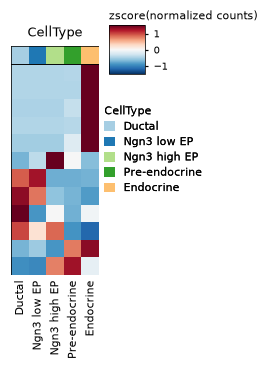

In [34]:
genes = ["Ins1","Gcg","Sst","Ghrl","Ppy","Neurog3",
         "Hes1","Sox9","Cpa1","Krt19","Pdx1","Nkx6-1"]
res = scp.pl.group_heatmap(adata, features=genes, group_by="CellType", layer="counts")
P = res.matrices["CellType"]

rn = [str(x) for x in r_hm_rows]
cn = [str(x) for x in r_hm_cols]
R = np.asarray(r_hm).reshape(len(rn), len(cn), order="F")
delta = float(np.nanmax(np.abs(R - P.loc[rn, cn].to_numpy())))
print("columns        :", cn)
print("max abs diff   :", f"{delta:.2e}")
print("identical      :", delta < 1e-5)
print("shared range   : %.3f .. %.3f" % (np.nanmin(R), np.nanmax(R)))

### 8.1 The dot heatmap

`add_dot=True` is the form most people actually use: colour carries the scaled
expression, dot area carries the fraction of cells above `exp_cutoff`. The cell
size is set by `dot_size` rather than chosen independently -- the dot at 100%
*is* the cell, and sizing the two separately makes the dots overflow and overlap.

In [35]:
%%R
grDevices::png("figures/r_groupheatmap.png", width = 5.2, height = 5.2,
               units = "in", res = 110, type = "cairo")
print(GroupHeatmap(pancreas_sub, features = genes, group.by = "CellType",
                   add_dot = TRUE, show_row_names = TRUE)$plot)
invisible(grDevices::dev.off())

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.


R — SCP,Python — pySCP
,

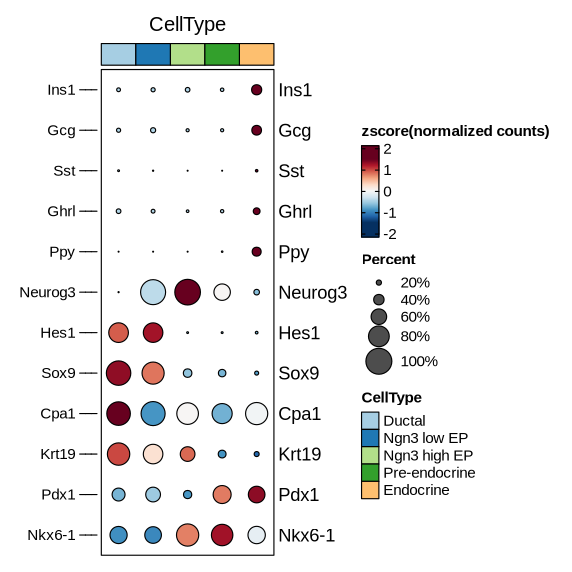
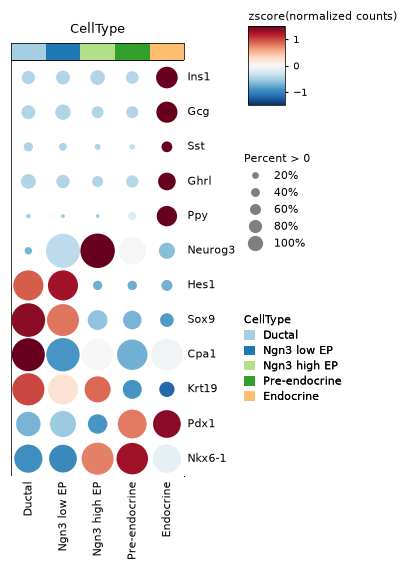

In [36]:
res_dot = scp.pl.group_heatmap(adata, features=genes, group_by="CellType", layer="counts",
                               add_dot=True, show_row_names=True)
res_dot.fig.savefig(FIG / "py_groupheatmap.png", dpi=110, bbox_inches="tight")
plt.close(res_dot.fig)
side_by_side("r_groupheatmap.png", "py_groupheatmap.png")

## 9. `cell_stat_plot` vs `CellStatPlot`

Composition rather than expression: how the cells of one categorical column
distribute across another. Eleven `plot_type`s in R; the seven cartesian and
polar ones are ported, plus `venn` and `upset`.

They are all views of **one** aggregation: a complete cross-tab of
`stat_by x group_by` within each split level, empty cells retained, divided by
the group total when `stat_type="percent"`. Get that table right and the
geometry is presentation.

In [37]:
%%R
p9 <- CellStatPlot(pancreas_sub, stat.by = "CellType", group.by = "Phase", plot_type = "bar")
ggplot2::ggsave("figures/r_cellstat_bar.png", p9, width = 5, height = 4,
                dpi = 110, device = grDevices::png, type = "cairo")

R — SCP,Python — pySCP
,

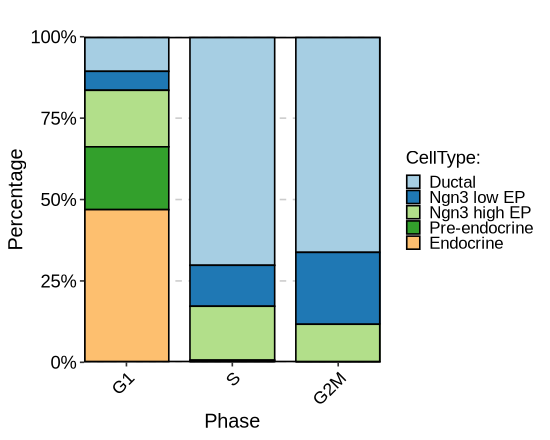
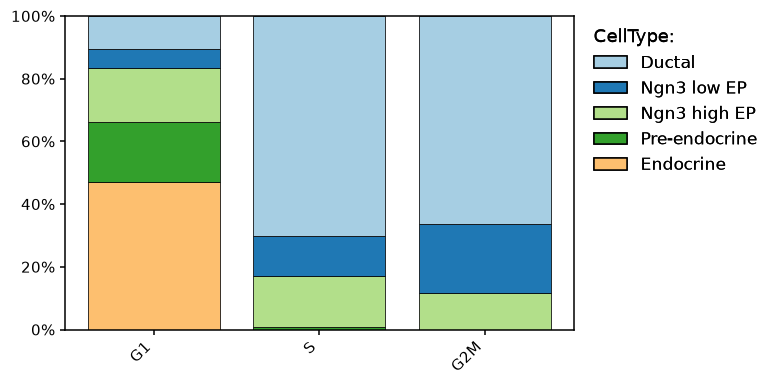

In [38]:
fig = scp.pl.cell_stat_plot(adata, "CellType", group_by="Phase", plot_type="bar",
                            panel_size=(2.9, 2.5))
fig.savefig(FIG / "py_cellstat_bar.png", dpi=110, bbox_inches="tight")
plt.close(fig)
side_by_side("r_cellstat_bar.png", "py_cellstat_bar.png")

### 9.1 The stacking order

Worth pausing on, because it is invisible until the two are side by side:
ggplot's `position_stack` fills **from the top down**, so the *first* factor
level is the topmost band. Accumulating in declared order instead — the obvious
implementation — turns the whole figure upside down while every number in it
stays correct.

In [39]:
tab = pd.crosstab(adata.obs["CellType"], adata.obs["Phase"])
pct = (tab / tab.sum(axis=0) * 100).round(1)
print(pct.to_string())
print()
print("column sums:", list((tab / tab.sum(axis=0)).sum(axis=0).round(6)))

Phase            G1     S   G2M
CellType                       
Ductal         10.6  70.2  66.2
Ngn3 low EP     5.8  12.6  22.1
Ngn3 high EP   17.4  16.6  11.7
Pre-endocrine  19.3   0.7   0.0
Endocrine      46.9   0.0   0.0

column sums: [1.0, 1.0, 1.0]


### 9.2 Ring and dot

`ring` reserves its hole the way SCP does, by prepending a dummy level to the
group factor. `dot` is the odd one out of the eleven: its y axis carries the
**category**, not the value, so it reads as a matrix of group x category with
size as the statistic.

In [40]:
%%R
p10 <- CellStatPlot(pancreas_sub, stat.by = "CellType", group.by = "Phase", plot_type = "ring")
ggplot2::ggsave("figures/r_cellstat_ring.png", p10, width = 5, height = 4,
                dpi = 110, device = grDevices::png, type = "cairo")

In addition: Warning message:
Removed 1 row containing missing values or values outside the scale range
(`geom_col()`). 


R — SCP,Python — pySCP
,

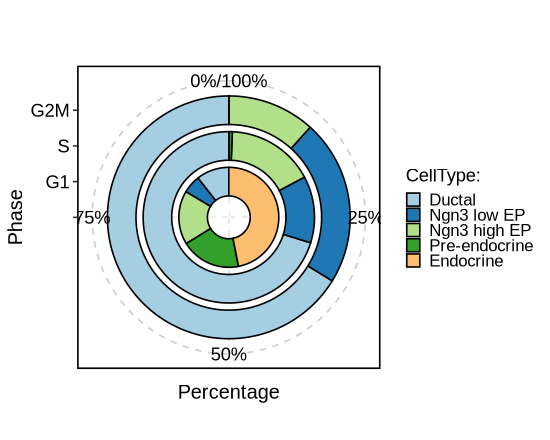
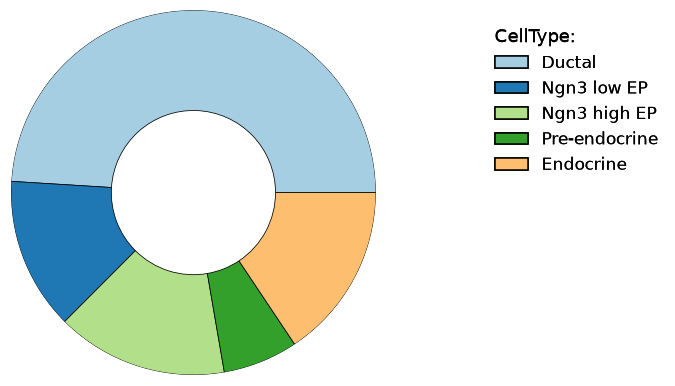

R — SCP,Python — pySCP
,

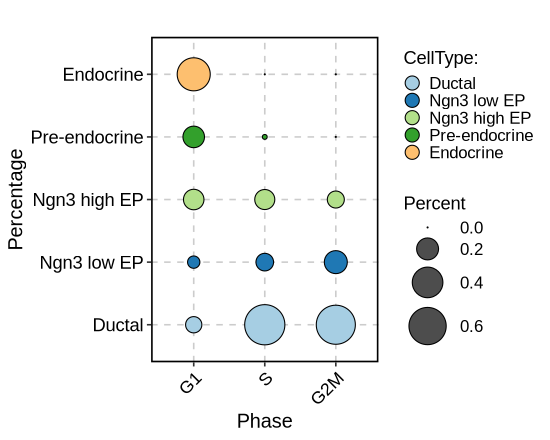
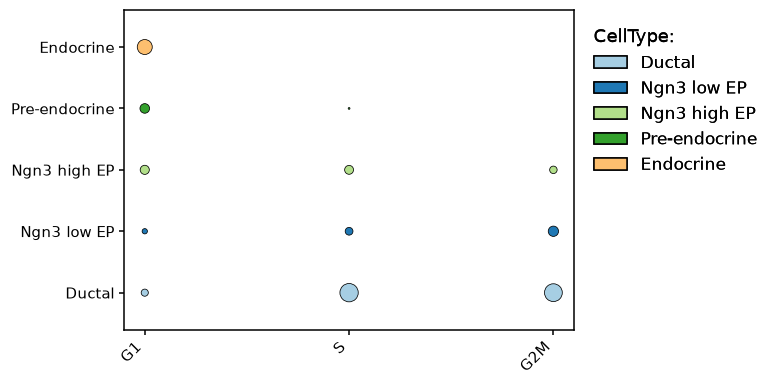

In [41]:
fig = scp.pl.cell_stat_plot(adata, "CellType", group_by="Phase", plot_type="ring",
                            panel_size=(2.9, 2.5))
fig.savefig(FIG / "py_cellstat_ring.png", dpi=110, bbox_inches="tight")
plt.close(fig)
display(side_by_side("r_cellstat_ring.png", "py_cellstat_ring.png"))

fig = scp.pl.cell_stat_plot(adata, "CellType", group_by="Phase", plot_type="dot",
                            panel_size=(2.9, 2.5))
fig.savefig(FIG / "py_cellstat_dot.png", dpi=110, bbox_inches="tight")
plt.close(fig)
display(side_by_side("r_cellstat_dot.png", "py_cellstat_dot.png"))

## 6. Findings

What this notebook has actually established, and what it has not.

| | |
|---|---|
| Level order | matches — declared factor order preserved end to end |
| `default_reduction` | picks `X_umap` under the scanpy naming |
| Palettes | verbatim slices byte-identical; interpolated ramp within the documented 1/255 tolerance |
| Colour algebra | all four blend modes and `adjcolors` identical |
| `matrix_process` | `zscore` (ddof=1) and `log2fc` identical |
| `cell_dim_plot` legend | identical text, order and counts |
| `feature_dim_plot` | nPos counts and percentages identical; same draw order, masking and winsorised scale |
| `feature_stat_plot` | all five geometries drawn; default grey85 striping, declared level order, dodged splits |
| `group_heatmap` | **matrix identical to R's `matrix_list` to 8.6e-07** — lib-normalise, aggregate, z-score all agree |
| `cell_stat_plot` | 9 of 11 plot types; cross-tab and stacking order match R |
| Normalisation | Seurat `NormalizeData` == scanpy `normalize_total(1e4)+log1p` to 3e-7 |
| Axis key | **diverges** — R `umap_1`, pySCP `UMAP_1` |

### The bug this notebook caught

On first run the legend came back as `Ductal, Pre-endocrine, Ngn3 low EP, Endocrine,
Ngn3 high EP` — the order the values happen to appear in the data, not the order declared
on the column. `cell_dim_plot` stored `as_ordered_categorical(...).to_numpy()`, which
flattens the Categorical away, and re-derived the levels further down from the raw values.
Every palette index and legend position shifted by that permutation.

It is exactly the failure class `docs/06_testing.md` is built around, it raised nothing,
and the synthetic test fixture could not see it because its declared order and its
appearance order coincided. Real data with a meaningful biological ordering exposed it
immediately. Fixed, with a regression test in `tests/test_cell_dim_plot.py`.

### Still open

- The `UMAP_` / `umap_` key mismatch above is unresolved; it needs a decision about whether
  to read Seurat's stored key or keep regenerating it.
- `panc8_sub.h5ad` is converted and committed but ships with **no reductions** — SCP
  computes them in its integration examples — so it cannot drive a dim plot until that
  workflow is ported.
- Everything beyond `cell_dim_plot` raises `NotImplementedError`. The next sections to add
  here are `feature_dim_plot` (milestone 3) and `feature_stat_plot` (milestone 4).